# Running SpatialFusion on Woappi Lab Unwounded data

In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pathlib as pl
import math
import tifffile

from matplotlib import patheffects

In [ ]:
# helper functions 

def plot_celltype_spatial_single_split_legend(
    df,
    color_by="celltype",
    sample_id=None,
    title=None,
    palette_dict=None,         # ✅ added
    palette_name="tab20",
    s=1.5,
    save_svg=True,
    output_prefix="spatial_plot",
    legend_title=None,
):
    """
    Nature Genetics–style spatial scatterplot for one sample,
    saving main plot as PNG (raster) and legend separately as SVG (vector).
    """
    sns.set_style("white")
    sns.set_context("talk")

    # --- Subset one sample ---
    if sample_id is not None:
        df = df[df["sample_id"] == sample_id].copy()
        if df.empty:
            raise ValueError(f"Sample ID '{sample_id}' not found in DataFrame.")

    # --- Colors ---
    unique_labels = sorted(df[color_by].dropna().unique())
    if palette_dict is not None and color_by in palette_dict:
        color_dict = palette_dict[color_by]
    else:
        palette = sns.color_palette(palette_name, n_colors=len(unique_labels))
        color_dict = dict(zip(unique_labels, palette))

    # --- Main plot ---
    fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
    sns.scatterplot(
        data=df,
        x="X_coord", y="Y_coord",
        hue=color_by, palette=color_dict,
        s=s, alpha=0.9, linewidth=0,
        rasterized=True, ax=ax, legend=False
    )
    ax.invert_yaxis(); ax.set_aspect("equal", adjustable="box")
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(""); ax.set_ylabel("")
    plt.tight_layout()

    # --- Save main figure ---
    fname_main = f"{output_prefix}_{sample_id or 'sample'}_main.png"
    fig.savefig(fname_main, dpi=300, bbox_inches="tight", transparent=True, format="png")
    print(f"Saved main figure: {fname_main}")

    # --- Legend ---
    fig_leg, ax_leg = plt.subplots(figsize=(3, 0.5 * len(unique_labels)), dpi=300)
    handles = [
        plt.Line2D([0], [0], marker='o', color='none', label=label,
                   markerfacecolor=color_dict[label], markersize=8)
        for label in unique_labels
    ]
    ax_leg.legend(handles=handles, loc="center left", frameon=False,
                  title=legend_title or color_by, title_fontsize=14, fontsize=14)
    ax_leg.axis("off")
    plt.tight_layout()

    if save_svg:
        fname_leg = f"{output_prefix}_{sample_id or 'sample'}_legend.svg"
        fig_leg.savefig(fname_leg, dpi=300, bbox_inches="tight", transparent=True, format="svg")
        print(f"Saved legend: {fname_leg}")

    plt.close(fig); plt.close(fig_leg)

def build_palettes_from_adata(adata, palette_specs):
    """
    Build labeled color palettes for categorical columns in adata.obs.


    Parameters
    ----------
    adata : AnnData
        Must have .obs DataFrame containing categorical columns.
    palette_specs : dict
        Mapping {column_name: palette} where palette can be:
          - a string palette name (e.g. "tab10")
          - a list of RGB colors (custom)

    Returns
    -------
    dict
        {column_name: {label: color}} mapping.
    """
    custom_palettes = {}

    for col, palette in palette_specs.items():
        if col not in adata.obs.columns:
            print(f"⚠️ Warning: '{col}' not found in adata.obs — skipping.")
            continue

        unique_vals = sorted(adata.obs[col].astype(str).dropna().unique())
        n_unique = len(unique_vals)

        # If user passed a name → generate via seaborn
        if isinstance(palette, str):
            pal_colors = sns.color_palette(palette, n_colors=n_unique)
        # If user passed a list → use directly
        elif isinstance(palette, (list, tuple)):
            pal_colors = palette[:n_unique]
        else:
            raise ValueError(f"Unsupported palette type for '{col}': {type(palette)}")

        color_dict = dict(zip(unique_vals, pal_colors))
        custom_palettes[col] = color_dict

    print(f"✅ Built palettes for {len(custom_palettes)} columns.")
    return custom_palettes


In [2]:
rawdata = sc.read_h5ad('/insomnia001/depts/morpheus/users/me2982/data/unwounded_woappi/data/adata_annotated.h5ad')

rawdata.obs = pd.concat([rawdata.obs, pd.DataFrame(rawdata.obsm['spatial'], index=rawdata.obs_names, columns=['X_coord','Y_coord'])],axis=1)

/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
rawdata_columns = list(rawdata.obs.columns)

In [4]:
region_df = rawdata.obs[rawdata_columns]
region_df['sample_id'] = 'YWV01_UW'
region_df

,orig.ident,nCount_Spatial,nFeature_Spatial,Region,alignment_clusters,spot_class,first_type,second_type,min_score,singlet_score,...,WoundSite,seurat_cluster.projected,seurat_cluster.projected.score,leverage.score,banksy_cluster_0.8,banksy_cluster_0.5,barcode,X_coord,Y_coord,sample_id
s_008um_00818_00075-1,YWV01_UW,764,512,Region2,7,doublet_uncertain,IRS I,Spinous III,1059.733345,1124.569085,...,Periphery,0,1.000000,1.845902,10,12,s_008um_00818_00075-1,21005.951173,29195.626137,YWV01_UW
s_008um_00456_00425-1,YWV01_UW,1169,834,Region2,16,doublet_certain,Cornified,Spinous III,1527.257149,1573.921446,...,Periphery,5,1.000000,1.749215,12,6,s_008um_00456_00425-1,15127.116271,34691.458628,YWV01_UW
s_008um_00612_00229-1,YWV01_UW,17,15,Region2,1,reject,uHF II,HF II,72.854319,112.854319,...,Periphery,2,0.585538,0.496680,15,10,s_008um_00612_00229-1,17672.662934,31601.249965,YWV01_UW
s_008um_00278_00647-1,YWV01_UW,77,72,Region2,8,reject,Papillary II,Skeletal Muscle,230.568492,270.568492,...,Periphery,12,0.505491,0.202202,1,7,s_008um_00278_00647-1,12223.024955,38191.239686,YWV01_UW
s_008um_00757_00068-1,YWV01_UW,73,71,Region2,5,reject,Basal III,Outer Bulge II,180.701995,220.701995,...,Periphery,2,0.653988,0.580959,4,4,s_008um_00757_00068-1,20033.031392,29067.388462,YWV01_UW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s_008um_00796_00072-1,YWV01_UW,150,142,Region2,1,reject,Langerhans cells,Mature ECs,403.859950,443.859950,...,Periphery,8,0.501802,0.530908,16,11,s_008um_00796_00072-1,20655.189690,29141.779398,YWV01_UW
s_008um_00835_00134-1,YWV01_UW,81,54,Region2,2,singlet,Skeletal Muscle,Pericyte I,169.082595,169.318892,...,Periphery,10,1.000000,0.152197,2,0,s_008um_00835_00134-1,21261.776621,30143.014557,YWV01_UW
s_008um_00207_00150-1,YWV01_UW,57,54,Region1,1,singlet,Pericyte II,Reticular II,182.661405,196.800415,...,Periphery,13,0.791048,3.307279,17,17,s_008um_00207_00150-1,11221.851951,30230.090545,YWV01_UW
s_008um_00256_00656-1,YWV01_UW,47,39,Region2,2,singlet,Skeletal Muscle,ILCs,121.851617,121.944667,...,Periphery,7,0.989467,0.050610,0,1,s_008um_00256_00656-1,11869.042500,38329.153353,YWV01_UW


In [7]:
tab_filtered = sns.color_palette()
tab_filtered = [c for i,c in enumerate(tab_filtered) if i not in [4,6]]

tab20_filtered = sns.color_palette('tab20') + sns.color_palette('tab20c')[:11]
tab20_filtered = [c for i,c in enumerate(tab20_filtered) if i not in [8,9,12,13]]

palette_specs = {
            "AnatomicalSite": tab_filtered,
            "metaclusters": tab20_filtered, 
        }

palette_dict_1 = build_palettes_from_adata(rawdata, palette_specs)

✅ Built palettes for 2 columns.


In [ ]:
plot_celltype_spatial_single_split_legend(
    region_df,
    color_by="AnatomicalSite",
    sample_id=None,
    title='Unwounded Anatomical Sites',
    palette_dict=palette_dict_1,
    s=1.5,
    save_svg=True,
    output_prefix="/insomnia001/depts/morpheus/users/me2982/data/unwounded_woappi/saved_figures/UW_anatomical_site",
    legend_title='Anatomical Type'
)

Saved main figure: /insomnia001/depts/morpheus/users/me2982/data/unwounded_woappi/saved_figures/UW_anatomical_site_sample_main.png
Saved legend: /insomnia001/depts/morpheus/users/me2982/data/unwounded_woappi/saved_figures/UW_anatomical_site_sample_legend.svg


In [38]:
plot_celltype_spatial_single_split_legend(
    region_df,
    color_by="metaclusters",
    sample_id=None,
    title='Unwounded Metaclusters',
   palette_dict=palette_dict_1,
    s=1.5,
    save_svg=True,
    output_prefix="/insomnia001/depts/morpheus/users/me2982/data/unwounded_woappi/saved_figures/UW_metaclusters",
    legend_title='Metaclusters'
)

Saved main figure: /insomnia001/depts/morpheus/users/me2982/data/unwounded_woappi/saved_figures/UW_metaclusters_sample_main.png
Saved legend: /insomnia001/depts/morpheus/users/me2982/data/unwounded_woappi/saved_figures/UW_metaclusters_sample_legend.svg


## Embed the Unwounded H&E

In [6]:
from spatialfusion.embed.embed import AEInputs, run_full_embedding
from spatialfusion.utils.pkg_ckpt import resolve_pkg_ckpt

In [7]:
# downlaoding estimated pathway activity

# Resolve packaged pretrained checkpoints
ae_ckpt = resolve_pkg_ckpt("checkpoint_dir_ae/spatialfusion-multimodal-ae.pt")
gcn_ckpt = resolve_pkg_ckpt("checkpoint_dir_gcn/spatialfusion-full-gcn.pt")

output_dir = '/insomnia001/depts/morpheus/users/me2982/data/unwounded_woappi'

pathway_matrix = pd.read_parquet(pl.Path(output_dir) / 'pathway_activation.parquet')
uni_df = pd.read_parquet(pl.Path(output_dir) / 'UNI_unwounded.parquet')
adata = sc.read_h5ad('/insomnia001/depts/morpheus/users/me2982/data/unwounded_woappi/data/adata_annotated.h5ad')
adata.obs["sample_id"] = "UW"

ae_inputs_by_sample = {
    "UW": AEInputs(adata=adata, z_uni=uni_df, z_scgpt=None),  # Assuming scGPT embeddings are not available for this sample
}

/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


### Embedding H&E Only

In [10]:

embeddings_df = run_full_embedding(
    ae_inputs_by_sample=ae_inputs_by_sample,
    ae_model_path=ae_ckpt,
    gcn_model_path=gcn_ckpt,
    device="cpu",
    combine_mode="z1",
    spatial_key='spatial',
    celltype_key='metaclusters',
    save_ae_dir=None,  # optional
)

out_path = "/insomnia001/depts/morpheus/users/me2982/data/unwounded_woappi/UW_HE_embed.parquet"
embeddings_df.to_parquet(out_path)

/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/spatialfusion/embed/embed.py:656: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feat

Processing AE in batches: 100%|██████████| 23/23 [00:00<00:00, 82.80it/s]
/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/spatialfusion/embed/embed.py:446: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Pleas

### Finetuned model and finetuned embedding

In [11]:
from spatialfusion.finetune.finetune import finetune_models

# MARISSA TODO: VISUALIZE EMBEDDINGS !!!!

In [19]:
import scanpy as sc
import pandas as pd

# extracting embeddings
emb_he_df = pd.read_parquet('/insomnia001/depts/morpheus/users/me2982/data/unwounded_woappi/UW_HE_embed.parquet')

adata = sc.read_h5ad("/insomnia001/depts/morpheus/users/me2982/data/unwounded_woappi/data/adata_annotated.h5ad")

/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# set index to cell_id if not already
emb_he_df = emb_he_df.set_index('cell_id')

# store embeddings in adata
adata.obsm['spatialfusion_he'] = emb_he_df.loc[adata.obs_names, ['0','1','2','3','4','5','6','7','8','9']].values

# run neighbors on the embeddings
sc.pp.neighbors(adata, use_rep='spatialfusion_he', n_neighbors=15)

# compute UMAP  
sc.tl.umap(adata)

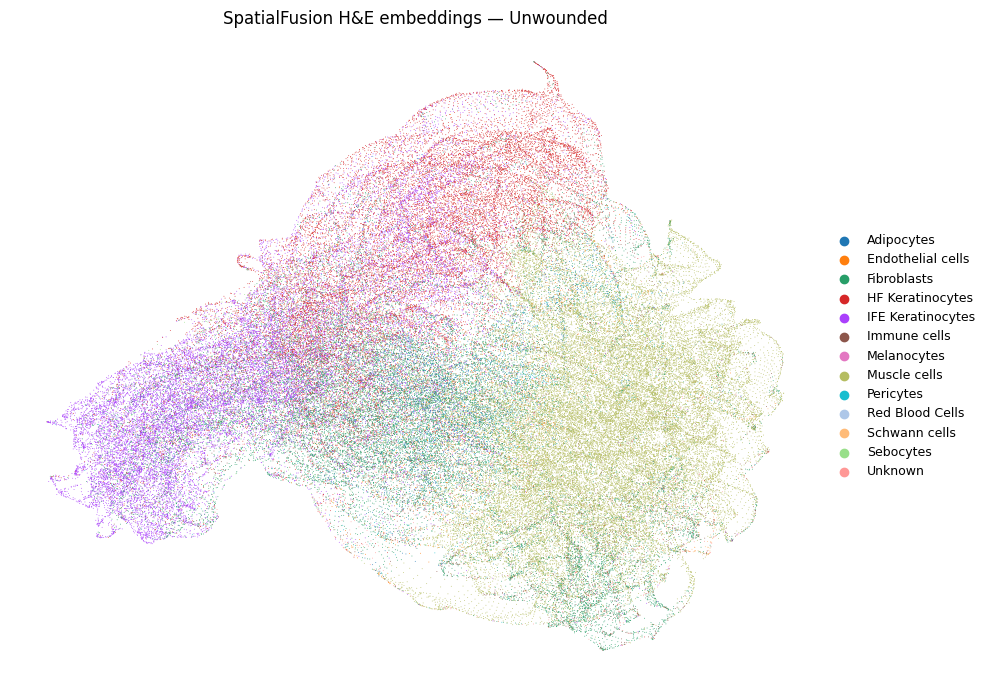

In [23]:
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(
    adata,
    color='metaclusters',
    frameon=False,
    legend_loc='right margin',
    legend_fontsize=9,
    size=1.5,
    ax=ax,
    show=False,
    title='SpatialFusion H&E embeddings — Unwounded'
)
plt.tight_layout()
plt.savefig('umap_metaclusters.png', dpi=300, bbox_inches='tight')
plt.show()

## SDM Benchmarks:
1. Adjusted Rand Index (ARI) 
2. Normalized Mutual Information (NMI)
3. Homogeneity (HOM)
4. Completeness (COM), which quantify agreement with pathologist annotations;
5. Percentage of Abnormal Spots (PAS) 
6. Spatial chaos (CHAOS), which assess spatial coherence. 

In [18]:
import numpy as np
import pandas as pd
from tqdm import tqdm

import scanpy as sc

from scipy.spatial import distance
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

In [19]:
# helper functions
def compute_PAS_fast(clusterlabel, location, k=10):
    clusterlabel = np.array(clusterlabel)
    location = np.array(location)

    # Fit NearestNeighbors (ignore self-match later)
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(location)
    distances, indices = nbrs.kneighbors(location)

    # Remove self (first column is self in most cases)
    neighbor_indices = indices[:, 1:]  # shape: (n_samples, k)

    # Check PAS condition
    mismatches = np.array([
        np.sum(clusterlabel[neighbor_indices[i]] != clusterlabel[i]) > (k / 2)
        for i in range(len(clusterlabel))
    ])

    return np.sum(mismatches) / len(clusterlabel)


def compute_CHAOS_fast(clusterlabel, location):
    clusterlabel = np.array(clusterlabel)
    location = np.array(location)
    matched_location = StandardScaler().fit_transform(location)

    clusterlabel_unique = np.unique(clusterlabel)
    dist_val = 0
    total_count = 0

    for k in tqdm(clusterlabel_unique, desc="Computing CHAOS"):
        cluster_mask = clusterlabel == k
        location_cluster = matched_location[cluster_mask]
        n = location_cluster.shape[0]

        if n <= 2:
            continue

        # Use NearestNeighbors to find 1-NN distances
        nbrs = NearestNeighbors(n_neighbors=2, algorithm='auto').fit(location_cluster)
        distances, _ = nbrs.kneighbors(location_cluster)

        # distances[:, 0] is zero (self), distances[:, 1] is nearest neighbor
        dist_val += np.sum(distances[:, 1])
        total_count += n

    return dist_val / total_count if total_count > 0 else np.nan


def compute_ASW_fast(adata, pred_key, spatial_key='spatial'):
    coords = adata.obsm[spatial_key]
    labels = adata.obs[pred_key]
    return silhouette_score(X=coords, labels=labels, metric='euclidean')

def compute_ARI(adata,gt_key,pred_key):
        return adjusted_rand_score(adata.obs[gt_key],adata.obs[pred_key])

def compute_NMI(adata,gt_key,pred_key):
    return normalized_mutual_info_score(adata.obs[gt_key],adata.obs[pred_key])

def compute_HOM(adata,gt_key,pred_key):
    return homogeneity_score(adata.obs[gt_key],adata.obs[pred_key])

def compute_COM(adata,gt_key,pred_key):
    return completeness_score(adata.obs[gt_key],adata.obs[pred_key])

In [21]:
adata

AnnData object with n_obs × n_vars = 113277 × 19059
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'Region', 'alignment_clusters', 'spot_class', 'first_type', 'second_type', 'min_score', 'singlet_score', 'seurat_cluster.sketched', 'seurat_clusters', 'metaclusters', 'AnatomicalSite', 'WoundSite', 'seurat_cluster.projected', 'seurat_cluster.projected.score', 'leverage.score', 'banksy_cluster_0.8', 'banksy_cluster_0.5', 'barcode', 'X_coord', 'Y_coord'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

In [24]:
adata = rawdata.copy()

# extracting embeddings
emb_he_df = pd.read_parquet('/insomnia001/depts/morpheus/users/me2982/data/unwounded_woappi/UW_HE_embed.parquet')

# setting the index to barcode
emb_he_df = emb_he_df.set_index('cell_id')

# inserting embeddings
adata.obsm['gcn_he'] = emb_he_df.loc[adata.obs_names,['0','1','2','3','4','5','6','7','8','9']]


/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


### Run Clustering
We want to set teh resolution to have the closest amount of set clusters (13).

In [26]:
# gcn
sc.pp.neighbors(adata, use_rep = 'gcn_he')
sc.tl.leiden(adata, resolution=0.12, flavor="igraph", n_iterations=2)

# Display number of clusters
adata.obs.leiden.value_counts()

leiden
1     23533
7     15462
4     11514
3      9527
8      9505
9      8153
5      6687
0      6559
6      6156
11     5842
12     4414
2      3798
10     2127
Name: count, dtype: int64

In [27]:
# Get cluster sizes
counts = adata.obs['leiden'].value_counts().sort_values(ascending=False)

# Make mapping: old → new (ranked by size)
mapping = {old: str(new) for new, old in enumerate(counts.index)}

# Apply mapping
adata.obs['leiden_gcn'] = adata.obs['leiden'].map(mapping).astype('category')

# (optional) sort categories by their new numeric label
adata.obs['leiden_gcn'].cat.reorder_categories(sorted(adata.obs['leiden_gcn'].cat.categories, key=int))

s_008um_00818_00075-1    7
s_008um_00456_00425-1    1
s_008um_00612_00229-1    1
s_008um_00278_00647-1    3
s_008um_00757_00068-1    1
                        ..
s_008um_00796_00072-1    7
s_008um_00835_00134-1    2
s_008um_00207_00150-1    8
s_008um_00256_00656-1    3
s_008um_00776_00050-1    1
Name: leiden_gcn, Length: 113277, dtype: category
Categories (13, object): ['0', '1', '2', '3', ..., '9', '10', '11', '12']

## Compute Metrics

In [28]:
def compute_all_metrics(adata, clustering_keys, ground_truth_key='path_region', spatial_key='spatial_px'):
    results = {}

    for method_name, cluster_key in clustering_keys.items():
        metrics = {
            'ARI': compute_ARI(adata, cluster_key, ground_truth_key),
            'NMI': compute_NMI(adata, cluster_key, ground_truth_key),
            'HOM': compute_HOM(adata, cluster_key, ground_truth_key),
            'COM': compute_COM(adata, cluster_key, ground_truth_key),
            'PAS': compute_PAS_fast(adata.obs[cluster_key], adata.obsm[spatial_key]),
            'CHAOS': compute_CHAOS_fast(adata.obs[cluster_key], adata.obsm[spatial_key]),
        }
        results[method_name] = metrics

    return pd.DataFrame(results)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

def format_number(value):
    """Format numbers: scientific notation if <0.01, else 2 decimals."""
    if pd.isna(value):
        return ""
    if abs(value) < 0.01 and value != 0:
        return f"{value:.0e}"  # 1 decimal in scientific notation, e.g. 3.4e-04
    else:
        return f"{value:.2f}"  # two decimals otherwise

def plot_benchmark_heatmap(
    results_df,
    title="Spatial clustering benchmark",
    savefig=None,
    metric_order=None,
):
    """
    Nature Genetics–style benchmarking heatmap showing method rankings across metrics.
    Allows manual control of metric order.
    """

    lower_better = {'PAS', 'CHAOS'}

    # --- Default metric order ---
    if metric_order is None:
        metric_order = list(results_df.index)

    # --- Normalize scores ---
    df_norm = results_df.copy()
    for metric in df_norm.index:
        vals = df_norm.loc[metric]
        if metric in lower_better:
            vals = -vals
        df_norm.loc[metric] = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)

    # --- Rank per metric ---
    ranks = results_df.copy()
    for metric in ranks.index:
        ranks.loc[metric] = results_df.loc[metric].rank(ascending=(metric in lower_better))

    # --- Prepare longform for plotting ---
    df_plot = df_norm.reset_index().melt(
        id_vars='index', var_name='Method', value_name='Normalized'
    ).rename(columns={'index': 'Metric'})

    df_plot['Raw'] = results_df.reset_index().melt(
        id_vars='index', var_name='Method', value_name='Raw'
    )['Raw']

    df_plot['Rank'] = ranks.reset_index().melt(
        id_vars='index', var_name='Method', value_name='Rank'
    )['Rank']

    # Add directional arrows
    df_plot['MetricLabel'] = df_plot['Metric'].apply(
        lambda m: f"{m} {'↓' if m in lower_better else '↑'}"
    )

    # --- Construct ordered MetricLabel list ---
    metric_order_labels = []
    for m in metric_order:
        arrow = '↓' if m in lower_better else '↑'
        metric_order_labels.append(f"{m} {arrow}")

    # --- Heatmap data matrix ---
    method_order = results_df.columns.tolist()
    df_matrix = df_plot.pivot_table(
        index="MetricLabel", columns="Method", values="Normalized"
    ).loc[metric_order_labels, method_order]

    # --- Aesthetics ---
    sns.set_theme(style="white", context="talk")

    fig, ax = plt.subplots(figsize=(1.3 * len(method_order), 0.8 * len(metric_order)), dpi=300)
    # Enhance contrast near the top (gamma correction)
    gamma = 3  ### THIS IS ONLY FOR THE COLOR FOR PLOTTING PURPOSES, NOT THE NUMBERS!
    df_matrix_contrast = df_matrix ** gamma
    sns.heatmap(
        df_matrix_contrast,
        #cmap="vlag",
        cmap = LinearSegmentedColormap.from_list(
            "vlag_red",
            ["#fee8ef",  # very light pink
             "#f4a3a8",  # pastel red
             "#d95858",  # mid red
             "#b40426"]  # vlag red (vivid crimson)
        ),
        cbar=False,
        ax=ax,
        linewidths=0,
        square=True,
    )

    # --- Adaptive text color (white on dark, black on light) ---
    #cmap = plt.get_cmap("vlag")
    cmap = LinearSegmentedColormap.from_list(
        "vlag_red",
        ["#fee8ef",  # very light pink
         "#f4a3a8",  # pastel red
         "#d95858",  # mid red
         "#b40426"]  # vlag red (vivid crimson)
    )

    for i, metric in enumerate(df_matrix.index):
        base_metric = metric.split()[0]
        for j, method in enumerate(df_matrix.columns):
            raw_val = results_df.loc[base_metric, method]
            norm_val = df_matrix.loc[metric, method]

            # Compute luminance for adaptive color
            rgb = np.array(cmap(norm_val)[:3])
            luminance = 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]
            text_color = "black" if luminance > 0.5 else "white"

            ax.text(
                j + 0.5, i + 0.5,
                format_number(raw_val),
                ha='center', va='center',
                color=text_color,
                fontsize=8,
                fontweight='normal',
            )

    # --- Formatting ---
    ax.set_title(title, fontsize=10, pad=14, fontweight='normal')
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10, fontweight='normal')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, fontweight='normal')

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()

    if savefig:
        fig.savefig(
            savefig,
            bbox_inches="tight",
            dpi=300,
            format=savefig.split('.')[-1],
            transparent=True
        )
        print(f"Saved: {savefig}")

    plt.show()

In [29]:
adata.obs = pd.concat([adata.obs,pathway_matrix],axis=1)

In [32]:
adata.obs["Region"]

s_008um_00818_00075-1    Region2
s_008um_00456_00425-1    Region2
s_008um_00612_00229-1    Region2
s_008um_00278_00647-1    Region2
s_008um_00757_00068-1    Region2
                          ...   
s_008um_00796_00072-1    Region2
s_008um_00835_00134-1    Region2
s_008um_00207_00150-1    Region1
s_008um_00256_00656-1    Region2
s_008um_00776_00050-1    Region2
Name: Region, Length: 113277, dtype: category
Categories (2, object): ['Region1', 'Region2']

In [33]:
clustering_keys = {
    'SpatialFusion (H&E)': 'leiden_gcn',
}

results_df = compute_all_metrics(adata, clustering_keys, ground_truth_key='metaclusters',spatial_key='spatial')

Computing CHAOS: 100%|██████████| 13/13 [00:00<00:00, 64.73it/s]


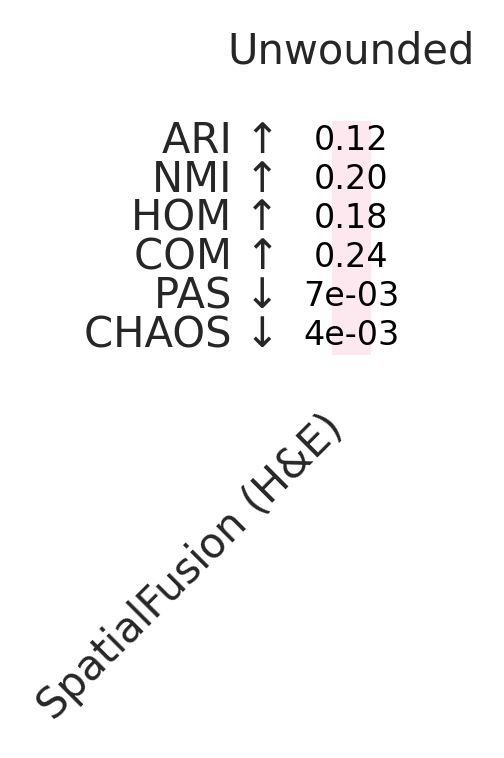

In [36]:
plot_benchmark_heatmap(results_df, title="Unwounded")


# RUNNING JUST THE MULTIMODAL ENCODER

In [1]:
# helper functions
import colorsys
from typing import Optional, Sequence, Mapping, Tuple, Dict, List

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb, to_hex
from sklearn.decomposition import PCA

def plot_embeddings(
    z1, z2, z_joint, labels, samples, label_title,
    palette="tab10", seed=42, max_cells=500_000
):

    rng = np.random.default_rng(seed)

    df = pd.DataFrame({"sample": samples, "label": labels}, index=z1.index)
    df["idx"] = np.arange(len(df))
    grouped = df.groupby("sample")

    # Determine how many cells per sample to keep
    total_samples = len(grouped)
    max_per_sample = max_cells // max(1, total_samples)

    # Subsample per sample group
    selected_indices = []
    for _, group in grouped:
        n = min(len(group), max_per_sample)
        selected_indices.extend(rng.choice(group["idx"].values, size=n, replace=False))

    # Subset everything
    z1 = z1.iloc[selected_indices]
    z2 = z2.iloc[selected_indices]
    z_joint = z_joint.iloc[selected_indices]
    labels = np.array(labels)[selected_indices]
    samples = np.array(samples)[selected_indices]

    # Apply PCA
    pca = PCA(n_components=2)
    explained_variance = []
    z1_pca = pca.fit_transform(z1.values)
    explained_variance.append(pca.explained_variance_ratio_)
    z2_pca = pca.fit_transform(z2.values)
    explained_variance.append(pca.explained_variance_ratio_)
    z_joint_pca = pca.fit_transform(z_joint.values)
    explained_variance.append(pca.explained_variance_ratio_)

    # Shuffle for plot order
    #perm = rng.permutation(len(labels))
    #z1_pca = z1_pca[perm]
    #z2_pca = z2_pca[perm]
    #z_joint_pca = z_joint_pca[perm]
    #labels = labels[perm]

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    point_size = 5  # keep a single source of truth for both scatter and legend markers

    def _strip_spines(ax):
        # Remove ALL spines (no plot borders)
        for spine in ax.spines.values():
            spine.set_visible(False)
        # No ticks and equal aspect
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")

    def plot_scatter(ax, emb, title, explained_variance, show_legend=False):
        sns.scatterplot(
            x=emb[:, 0],
            y=emb[:, 1],
            hue=labels,
            palette=palette,
            s=point_size,
            ax=ax,
            linewidth=0,
            alpha=0.8,
            legend="full" if show_legend else False,
        )
        ax.set_title(title, fontsize=25)
        ax.set_xlabel(f"PC1 ({explained_variance[0]*100:.1f}%)")
        ax.set_ylabel(f"PC2 ({explained_variance[1]*100:.1f}%)")
        _strip_spines(ax)

    plot_scatter(axes[0], z1_pca, "H&E (PCA)", explained_variance[0])
    plot_scatter(axes[1], z2_pca, "RNA (PCA)", explained_variance[1])
    plot_scatter(axes[2], z_joint_pca, "Joint (PCA)", explained_variance[2], show_legend=True)

    # Extract and remove subplot legend
    handles, labels_ = axes[2].get_legend_handles_labels()
    if axes[2].legend_ is not None:
        axes[2].legend_.remove()

    # Make legend marker sizes match the scatter point size
    # (handles from seaborn are PathCollections for the color items)
    for h in handles:
        if hasattr(h, "set_sizes"):
            h.set_sizes([point_size])  # one marker per legend entry

    # Add shared figure legend (text size follows rcParams; markers already matched)
    fig.legend(
        handles,
        labels_,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        title=label_title,
        scatterpoints=1,     # one marker per legend entry
        markerscale=10,     # keep scale = 1 to respect set_sizes above
        frameon=False,       # optional: no border around the legend
        fontsize=16,        # control legend text size here
        title_fontsize=18,
    )

    plt.tight_layout()
    plt.show()

In [2]:
from spatialfusion.embed.embed import AEInputs, run_full_embedding

# Standard library
import logging
import os
import warnings
import pathlib as pl

# Third-party libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import shapely.wkb
import tifffile
import timm
import torch
from PIL import Image
from tqdm.notebook import tqdm
from torchvision import transforms



/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [ ]:
from spatialfusion.utils.pkg_ckpt import resolve_pkg_ckpt
from spatialfusion.embed.embed import load_paired_ae, ae_from_arrays

: 

In [ ]:
# previously computed embeddings
output_dir = '/insomnia001/depts/morpheus/users/me2982/data/unwounded_woappi'
uni_df = pd.read_parquet(pl.Path(output_dir) / 'UNI_unwounded.parquet')
scgpt_df = pd.read_parquet(pl.Path(output_dir) / 'scGPT.parquet')

adata_path = "/insomnia001/depts/morpheus/users/me2982/data/unwounded_woappi/data/adata_humanized.h5ad"
adata = sc.read_h5ad(adata_path)

sample_name = "Unwounded YWV01_UW"

# read in wsi image (for visualization later)
source_image_path = '/insomnia001/depts/morpheus/users/me2982/data/unwounded_woappi/dropbox_data/B6-298-UW_Scan3.qptiff'

with tifffile.TiffFile(source_image_path) as tif:
    wsi = tif.series[0].asarray()

ae_inputs_by_sample = {
    sample_name: AEInputs(adata=adata, z_uni=uni_df, z_scgpt=scgpt_df),
}

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Resolve packaged pretrained checkpoints
ae_ckpt = resolve_pkg_ckpt("checkpoint_dir_ae/spatialfusion-multimodal-ae.pt")

# Infer dimensions
d1_dim, d2_dim = ae_inputs_by_sample[sample_name].z_uni.shape[1], ae_inputs_by_sample[sample_name].z_scgpt.shape[1]

# Load AE model
ae_model = load_paired_ae(ae_ckpt, d1_dim, d2_dim, latent_dim=64, device=device)

# Run AE embedding
z1_df, z2_df, z_joint_df = ae_from_arrays(
    ae_model,
    ae_inputs_by_sample[sample_name],
    device=device,
    combine_mode="average",  # or "concat", "z1", "z2",
    batch_size=None,  # optional, can be tuned based on dataset size and GPU memory, None automatically determines batch size based on input size and available memory
)

In [ ]:
# retrieve cell type and sample information for plotting
labels_ct = adata.obs['metaclusters'].ravel()

samples = [sample_name for _ in range(z1_df.shape[0])]

/tmp/ipykernel_764821/1115489653.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  labels_ct = adata.obs['metaclusters'].ravel()


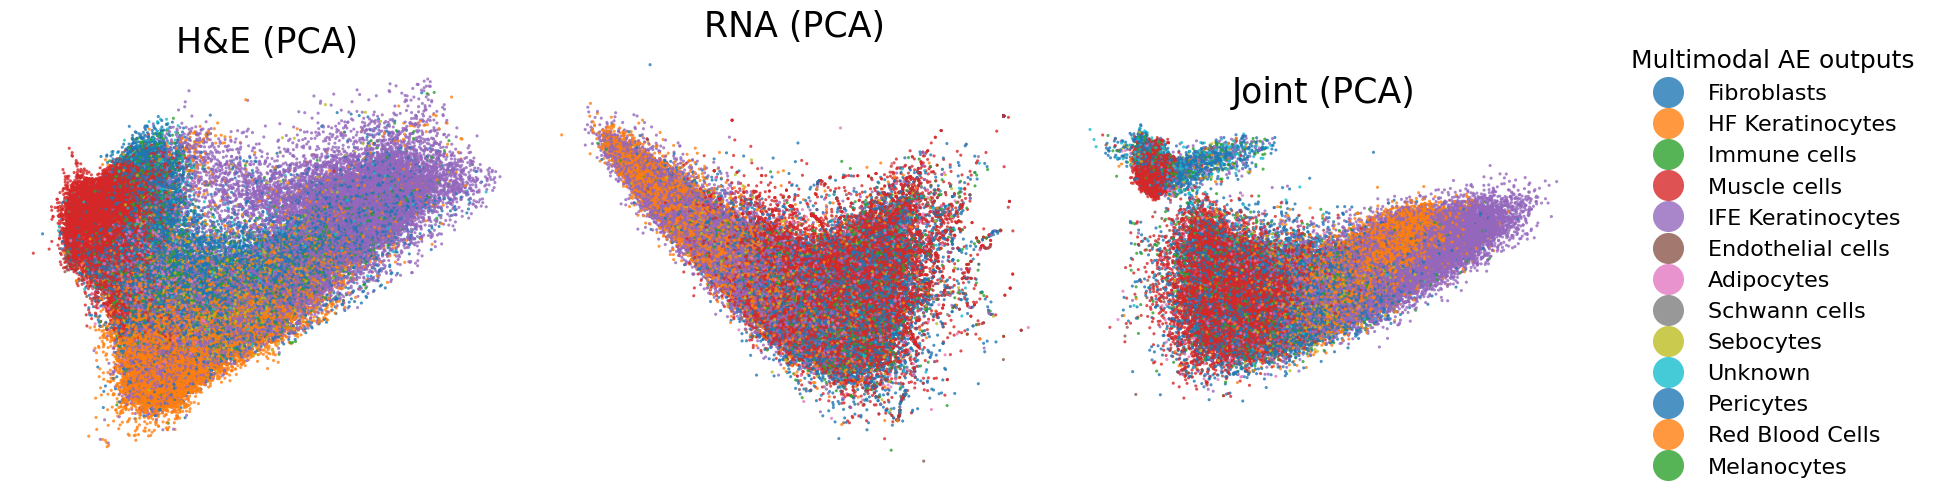

In [ ]:
# Colored by broad cell types
plot_embeddings(
    z1_df, z2_df, z_joint_df, labels_ct, samples, 'Multimodal AE outputs',
    palette="tab10", seed=42, max_cells=500_000
)